# 🎧 Urban Sound Classification: CNN vs. SVM
## ECE 176 — Introduction to Deep Learning | UC San Diego | March 2026
**Author:** Duy Nguyen | PID: A18513063

---

## 📋 Project Overview

This notebook is the complete implementation and report for ECE 176 Final Project.

**Research Question:** Does treating audio as an image (CNN on mel spectrograms) outperform traditional handcrafted feature methods (SVM on MFCCs) for urban sound classification? And critically — which approach is more reliable when deployed in noisy real-world environments?

**Dataset:** [UrbanSound8K](https://urbansounddataset.weebly.com/urbansound8k.html) — 8,732 audio clips across 10 urban sound classes, evaluated under the official 10-fold cross-validation protocol.

---

## 🗂️ Notebook Structure

| Part | Description |
|------|-------------|
| **Part 1: Setup** | Environment, GPU, Drive, dataset |
| **Part 2: Feature Engineering** | Audio → log-mel spectrogram, MFCC extraction |
| **Part 3: Model Architecture** | UrbanCNN (~1.2M params), SVM+MFCC baseline |
| **Part 4: Training** | Multi-session training with checkpoint resume |
| **Part 5: Results** | 10-fold CV results, confusion matrix |
| **Part 6: Noise Robustness** | ⭐ Novel contribution — degradation curves under AWGN |

---

## 📊 Final Results (Clean Data)

| Model | Mean Accuracy | Std |
|-------|--------------|-----|
| **UrbanCNN** (log-mel spectrogram) | **73.29%** | ±5.19% |
| SVM+MFCC baseline | 66.10% | ±5.03% |
| **CNN advantage** | **+7.19 pp** | — |

> **Key finding:** CNN wins on clean data by 7.19 pp. The noise robustness experiment (Part 6) reveals which model is safer to deploy in the real world.

---

## ⚙️ Hardware Requirements

- **Recommended:** A100 or T4 GPU (Google Colab Pro)
- Runtime → Change runtime type → GPU
- All checkpoints persist to Google Drive — safe to resume across sessions

---
# Part 1: Environment Setup

This section handles all one-time setup: cloning the repo, verifying GPU, mounting Google Drive, downloading the dataset, and installing dependencies.

**Run these cells once at the start of every Colab session.**

## Cell 0 — Clone GitHub Repository

Pulls the project code from GitHub using a personal access token stored as a Colab Secret (never hardcoded).

**Why clone instead of uploading files?** Colab sessions are ephemeral — Drive persists data, but `/content/` resets. Cloning from GitHub on every session ensures the latest code is always used and makes version control easy.

- `userdata.get('GITHUB_TOKEN')` — reads the token from Colab Secrets (Secrets tab in the left sidebar)
- `git pull` — if already cloned, just updates to latest commit instead of re-cloning
- `sys.path.insert` — adds the repo to Python's import path so `from core import ...` works

In [1]:
# ── Cell 0: Clone repo from GitHub ──────────────────────────────
import os
from google.colab import userdata

# Pull token from Colab Secrets (never hardcode it)
token = userdata.get('GITHUB_TOKEN')
!git config --global user.email "dun011@ucsd.edu"
!git config --global user.name "DanielNg520"

REPO = 'DanielNg520/Urbansound8k-spectrogram-CNN'  # ← edit this

# Clone or pull latest
if os.path.exists('/content/urbansound'):
    # Already cloned — just pull latest changes
    %cd /content/urbansound
    !git pull https://{token}@github.com/{REPO}.git main
else:
    !git clone https://{token}@github.com/{REPO}.git /content/urbansound
    %cd /content/urbansound

# Add to Python path so core/ imports work
import sys
sys.path.insert(0, '/content/urbansound')

print('Repo ready.')

Cloning into '/content/urbansound'...
remote: Enumerating objects: 51, done.
remote: Counting objects: 100% (51/51), done.
remote: Compressing objects: 100% (38/38), done.
remote: Total 51 (delta 24), reused 38 (delta 12), pack-reused 0 (from 0)
Receiving objects: 100% (51/51), 78.92 KiB | 1.38 MiB/s, done.
Resolving deltas: 100% (24/24), done.
/content/urbansound
Repo ready.


## Cell 1 — Check Hardware

Detects the available GPU and sets the global `DEVICE` variable used throughout the notebook.

**Why this matters:** All tensors and model parameters must be on the same device. Setting `DEVICE` once globally lets every subsequent cell use `tensor.to(DEVICE)` without hardcoding `'cuda'` or `'cpu'`.

- **T4 (15.6 GB):** Standard free/Pro option. Use `BATCH_SIZE=64`
- **V100 (16 GB):** Good middle ground. Use `BATCH_SIZE=128`
- **A100 (40 GB):** Fastest. Use `BATCH_SIZE=256`

In [2]:
# ── Cell 1: Check hardware ──────────────────────────────────────
import torch

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem  = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'GPU: {gpu_name}')
    print(f'VRAM: {gpu_mem:.1f} GB')
    DEVICE = torch.device('cuda')
else:
    print('No GPU! Go to Runtime → Change runtime type → GPU')
    DEVICE = torch.device('cpu')

print(f'Device: {DEVICE}')
print(f'PyTorch: {torch.__version__}')

GPU: Tesla T4
VRAM: 15.6 GB
Device: cuda
PyTorch: 2.10.0+cu128


## Cell 2 — Mount Google Drive & Set Paths

Mounts Google Drive as a filesystem and defines all directory paths used throughout the project.

**Why Google Drive?** Colab sessions disconnect after ~12 hours. All checkpoints, cached features, and results are saved to Drive so training can resume seamlessly in a new session without losing progress.

```
ECE176_project/
├── UrbanSound8K/           ← raw audio + metadata CSV
│   ├── audio/fold1/ ... fold10/
│   └── metadata/UrbanSound8K.csv
├── checkpoints/            ← foldN_best.pt, foldN_resume.pt, progress.json
├── results/                ← svm_results.json, cnn_results.json, noise_results.json
└── cache/                  ← mfcc.npz (pre-computed features)
```

In [3]:
# ── Cell 2: Mount Drive & set paths ────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import os

DRIVE_ROOT     = '/content/drive/MyDrive/ECE176_project'
DATASET_ROOT   = os.path.join(DRIVE_ROOT, 'UrbanSound8K')
CHECKPOINT_DIR = os.path.join(DRIVE_ROOT, 'checkpoints')
RESULTS_DIR    = os.path.join(DRIVE_ROOT, 'results')
CACHE_DIR      = os.path.join(DRIVE_ROOT, 'cache')

for d in [CHECKPOINT_DIR, RESULTS_DIR, CACHE_DIR]:
    os.makedirs(d, exist_ok=True)

print('Drive mounted.')
print(f'Dataset: {DATASET_ROOT}')
print(f'Dataset exists: {os.path.exists(DATASET_ROOT)}')
print(f'CSV exists: {os.path.exists(os.path.join(DATASET_ROOT, "metadata", "UrbanSound8K.csv"))}')

Mounted at /content/drive
Drive mounted.
Dataset: /content/drive/MyDrive/ECE176_project/UrbanSound8K
Dataset exists: True
CSV exists: True


## Cell 3 — Dataset Download

Downloads UrbanSound8K from Kaggle using the `kagglehub` API and reorganizes it into the expected directory structure. Skips automatically if the dataset is already in Drive.

**One-time operation** — after the first run this cell always prints `Skipping.`

**Kaggle credentials** are read from Colab Secrets (`KAGGLE_USERNAME`, `KAGGLE_KEY`) — get these from your Kaggle account → Settings → API → Create New Token.

In [4]:
# ── Cell 3: Dataset setup ────────────────────────────────────────
import os
import shutil
import kagglehub
from google.colab import userdata
import json

dst = '/content/drive/MyDrive/ECE176_project/UrbanSound8K'
csv_path = os.path.join(dst, 'metadata', 'UrbanSound8K.csv')

if os.path.exists(csv_path):
    print('Dataset already in Drive with correct structure. Skipping.')
else:
    # Set Kaggle credentials
    os.makedirs('/root/.kaggle', exist_ok=True)
    with open('/root/.kaggle/kaggle.json', 'w') as f:
        json.dump({
            "username": userdata.get('KAGGLE_USERNAME'),
            "key":      userdata.get('KAGGLE_KEY')
        }, f)
    os.chmod('/root/.kaggle/kaggle.json', 0o600)

    # Download
    print('Downloading UrbanSound8K...')
    src = kagglehub.dataset_download('chrisfilo/urbansound8k')
    print(f'Downloaded to: {src}')

    # Delete any previous bad copy
    if os.path.exists(dst):
        print('Removing previous copy...')
        shutil.rmtree(dst)

    # Rebuild correct structure
    os.makedirs(os.path.join(dst, 'audio'), exist_ok=True)
    os.makedirs(os.path.join(dst, 'metadata'), exist_ok=True)

    for item in os.listdir(src):
        full = os.path.join(src, item)
        if item.startswith('fold'):
            print(f'  Copying {item}...')
            shutil.copytree(full, os.path.join(dst, 'audio', item))
        elif item.endswith('.csv'):
            print(f'  Copying {item}...')
            shutil.copy2(full, os.path.join(dst, 'metadata', 'UrbanSound8K.csv'))

    # Verify
    print(f'\nmetadata/UrbanSound8K.csv: {os.path.exists(csv_path)}')
    print(f'audio/ folders: {sorted(os.listdir(os.path.join(dst, "audio")))}')
    print('Done.')

Dataset already in Drive with correct structure. Skipping.


## Cell 4 — Install Dependencies

Installs the three non-standard libraries needed:
- **`librosa`** — audio loading and feature extraction (mel spectrograms, MFCCs)
- **`scikit-learn`** — SVM classifier, StandardScaler, accuracy metrics
- **`tqdm`** — progress bars (used internally by librosa)

Everything else (PyTorch, NumPy, pandas, matplotlib) is pre-installed on Colab.

In [5]:
# ── Cell 4: Install dependencies ────────────────────────────────
!pip install -q librosa scikit-learn tqdm

---
# Part 2: Feature Engineering

The central design choice in audio classification is **how to represent sound numerically**.

This project implements two competing representations:

### Representation 1: Log-Mel Spectrogram (for CNN)
Converts raw waveform → 2D image showing how energy is distributed across frequency bands over time.

```
Raw audio (88,200 samples @ 22,050 Hz)
    ↓  Short-Time Fourier Transform (STFT)
Power spectrogram (frequency × time)
    ↓  Mel filterbank (perceptual frequency scaling)
Mel spectrogram (128 mel bins × 128 time frames)
    ↓  Power-to-dB + [0,1] normalization
Log-mel image (128 × 128 float32)
```

### Representation 2: MFCC Feature Vector (for SVM)
Applies the Discrete Cosine Transform on top of the mel spectrogram to decorrelate features.

```
Raw audio
    ↓  MFCC extraction (40 coefficients)
Per-frame MFCC matrix (40 × ~172 frames)
    ↓  Temporal aggregation: mean + std per coefficient
80-dimensional feature vector
```

**Key difference:** The CNN sees the full time-frequency image and learns which patterns matter. The SVM sees only statistical summaries, losing temporal structure but gaining robustness to some noise types.

## Cell 5 — Core Utilities: Constants, Audio Loading, Feature Extraction

This cell defines everything downstream cells depend on. It must be run before any other code.

### Constants
| Constant | Value | Meaning |
|----------|-------|---------|
| `SAMPLE_RATE` | 22,050 Hz | Resample all audio to this rate |
| `CLIP_DURATION` | 4.0 s | Pad/trim all clips to exactly 4 seconds (88,200 samples) |
| `N_MFCC` | 40 | Number of MFCC coefficients to extract |
| `N_MELS` | 128 | Number of mel frequency bins |
| `HOP_LENGTH` | 512 | STFT hop size (controls time resolution) |
| `N_FFT` | 2048 | STFT window size (controls frequency resolution) |
| `MEL_LENGTH` | 128 | Target number of time frames in the mel spectrogram |

### `load_audio(path)`
Loads any audio format via librosa, resamples to 22,050 Hz, and pads/trims to exactly 4 seconds. Returns silent zeros on load failure (robust to corrupted files).

### `extract_mel(y)`
Computes the log-mel spectrogram and normalizes pixel values to [0, 1]. The normalization is per-clip (not global), which makes the CNN invariant to absolute volume — it classifies sound texture, not loudness.

### `extract_mfcc(y)`
Extracts 40 MFCCs and computes their mean and standard deviation across time frames, producing an 80-D vector. Mean captures average spectral shape; std captures how much the shape varies over time.

### `get_fold_splits(meta)`
A generator that yields `(test_fold, train_df, test_df)` for each of the 10 folds, following UrbanSound8K's official cross-validation protocol.

In [6]:
# ── Cell 5: Core utilities (inline — no local files needed) ─────
import numpy as np
import pandas as pd
import librosa
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import json

# ── Constants ──
CLASSES = ['air_conditioner','car_horn','children_playing','dog_bark',
           'drilling','engine_idling','gun_shot','jackhammer','siren','street_music']
SAMPLE_RATE = 22050
CLIP_DURATION = 4.0
N_MFCC = 40
N_MELS = 128
HOP_LENGTH = 512
N_FFT = 2048
MEL_LENGTH = 128

# ── Audio loading ──
def load_audio(path, sr=SAMPLE_RATE, duration=CLIP_DURATION):
    try:
        y, _ = librosa.load(path, sr=sr, duration=duration, mono=True)
    except:
        return np.zeros(int(sr * duration), dtype=np.float32)
    target_len = int(sr * duration)
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    return y[:target_len].astype(np.float32)

# ── Feature extraction ──
def extract_mfcc(y, sr=SAMPLE_RATE):
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC, n_fft=N_FFT, hop_length=HOP_LENGTH)
    return np.concatenate([mfcc.mean(axis=1), mfcc.std(axis=1)])

def extract_mel(y, sr=SAMPLE_RATE, fixed_length=MEL_LENGTH):
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS,
                                          n_fft=N_FFT, hop_length=HOP_LENGTH, fmax=8000)
    log_mel = librosa.power_to_db(mel, ref=np.max)
    if log_mel.shape[1] < fixed_length:
        log_mel = np.pad(log_mel, ((0,0),(0, fixed_length - log_mel.shape[1])),
                         constant_values=log_mel.min())
    else:
        log_mel = log_mel[:, :fixed_length]
    lo, hi = log_mel.min(), log_mel.max()
    if hi - lo > 1e-6:
        log_mel = (log_mel - lo) / (hi - lo)
    return log_mel.astype(np.float32)

# ── Metadata ──
def load_metadata(root):
    return pd.read_csv(os.path.join(root, 'metadata', 'UrbanSound8K.csv'))

def audio_path(root, fold, fname):
    return os.path.join(root, 'audio', f'fold{fold}', fname)

def get_fold_splits(meta):
    for fold in sorted(meta['fold'].unique()):
        yield fold, meta[meta['fold'] != fold].copy(), meta[meta['fold'] == fold].copy()

print('Core utilities loaded.')

Core utilities loaded.


---
# Part 3: Model Architecture

## Why CNN for Audio?

Audio can be treated as an image recognition problem. A log-mel spectrogram is a 2D array where:
- **Rows** = frequency bands (low to high, perceptually scaled)
- **Columns** = time frames
- **Pixel value** = energy at that frequency at that time

CNNs excel at detecting local patterns in 2D grids — the same property that makes them powerful for images makes them powerful for spectrograms. A dog bark has a characteristic spectrotemporal texture; a siren has a distinctive frequency sweep. The CNN learns these patterns automatically from data.

## Cell 6 — Dataset Class & Model Definitions

### `MelDataset`
A PyTorch `Dataset` that loads audio on-the-fly during training. Key design choices:
- **On-the-fly loading:** Doesn't preload all spectrograms into RAM (would require ~10 GB)
- **Data augmentation (training only):**
  - *Random temporal shift* ±10%: shifts the waveform left/right, teaching the model that sound class is position-invariant
  - *Low-amplitude Gaussian jitter* (σ=0.005): adds very slight noise to prevent over-reliance on exact waveform values

### `ConvBlock`
A reusable building block: `Conv2d(3×3) → BatchNorm → ReLU → MaxPool(2×2)`
- **BatchNorm** stabilizes training by normalizing activations, enabling higher learning rates
- **MaxPool(2×2)** halves spatial dimensions, doubling receptive field size

### `UrbanCNN` Architecture
```
Input: (1, 128, 128)  ← single-channel mel spectrogram
  ConvBlock(1→32):   (32, 64, 64)
  ConvBlock(32→64):  (64, 32, 32)
  ConvBlock(64→128): (128, 16, 16)
  ConvBlock(128→256):(256, 8, 8)
  Flatten:           (16384,)
  Linear(16384→512) + ReLU + Dropout(0.5)
  Linear(512→10)    ← 10 class logits
```
**Total parameters:** ~1.2M

**Dropout(0.5):** Randomly zeros 50% of neurons during training, forcing redundant representations. Acts as implicit ensemble of 2^512 subnetworks.

In [7]:
# ── Cell 6: Dataset + Models ─────────────────────────────────────

class MelDataset(Dataset):
    def __init__(self, df, root, augment=False):
        self.df = df.reset_index(drop=True)
        self.root = root
        self.augment = augment

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        y = load_audio(audio_path(self.root, row['fold'], row['slice_file_name']))
        if self.augment:
            shift = int(np.random.uniform(-0.1, 0.1) * len(y))
            y = np.roll(y, shift)
            y += np.random.normal(0, 0.005, y.shape).astype(y.dtype)
        mel = torch.from_numpy(extract_mel(y)).unsqueeze(0)
        return mel, torch.tensor(int(row['classID']), dtype=torch.long)


class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, pool=True):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(),
            nn.MaxPool2d(2) if pool else nn.Identity()
        )
    def forward(self, x): return self.block(x)


class UrbanCNN(nn.Module):
    def __init__(self, n_classes=10, dropout=0.5):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(1,   32),
            ConvBlock(32,  64),
            ConvBlock(64,  128),
            ConvBlock(128, 256),
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256*8*8, 512),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, n_classes)
        )
    def forward(self, x): return self.head(self.features(x))


print('Dataset and model classes defined.')

Dataset and model classes defined.


---
# Part 4: Training

## Training Strategy

**10-fold cross-validation:** Each fold is used as the test set exactly once. The model never sees its test fold's data during training. This is mandatory for UrbanSound8K — the dataset creators explicitly warn against random train/test splits because clips from the same recording appear in multiple folds; random splits cause data leakage.

**Multi-session training:** Each fold trains for 60 epochs. On Colab's free tier, sessions disconnect before all folds complete. The checkpoint system handles this:
- Every 5 epochs: save a *resume checkpoint* (model + optimizer + scheduler state)
- Whenever validation improves: overwrite the *best checkpoint* (model weights only)
- On reconnect: load resume checkpoint and continue from where it stopped
- When a fold finishes: log it in `progress.json` and skip it on future runs

**Optimizer:** Adam with `lr=1e-3`, `weight_decay=1e-4`
**Scheduler:** Cosine Annealing — smoothly decays learning rate from 1e-3 to ~0 over 60 epochs, improving final convergence quality over fixed LR.

## Cell 7 — Training Configuration

Sets hyperparameters. Adjust `BATCH_SIZE` and `NUM_WORKERS` based on your GPU:

| GPU | BATCH_SIZE | NUM_WORKERS |
|-----|-----------|-------------|
| T4  | 64 | 2 |
| V100 | 128 | 4 |
| A100 | 256 | 4 |

**Why these values?**
- Larger batch = faster training but worse generalization (gradient becomes too average)
- 64 is a standard balance for ~800-sample per-class datasets like this
- `NUM_WORKERS` = number of parallel CPU processes for data loading; more = faster, but crashes if set too high

In [8]:
# ── Cell 7: Config ───────────────────────────────────────────────
# Adjust these based on your GPU
# T4:   BATCH_SIZE=64,  NUM_WORKERS=2
# V100: BATCH_SIZE=128, NUM_WORKERS=4
# A100: BATCH_SIZE=256, NUM_WORKERS=4

BATCH_SIZE  = 64     # ← change based on GPU above
EPOCHS      = 60
LR          = 1e-3
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 2      # ← change based on GPU above

PROGRESS_FILE = os.path.join(CHECKPOINT_DIR, 'progress.json')

print(f'Batch size: {BATCH_SIZE}')
print(f'Epochs: {EPOCHS}')
print(f'Progress file: {PROGRESS_FILE}')

Batch size: 64
Epochs: 60
Progress file: /content/drive/MyDrive/ECE176_project/checkpoints/progress.json


## Cell 8 — Training Helpers

Defines all helper functions for training, evaluation, and safe file I/O.

### `train_epoch(model, loader, opt, criterion, scaler)`
One full pass through the training set. Uses **mixed precision** (`torch.amp.autocast`) when a CUDA scaler is provided — computes forward pass in float16, reducing memory by ~2× and increasing throughput ~1.5×.

### `eval_model(model, loader)`
Runs inference in `torch.no_grad()` context (disables gradient computation, saving memory) and returns all labels and predictions as numpy arrays.

### `load_progress()` / `save_progress(prog)`
**Atomic write pattern** for `progress.json`:
1. Write to `progress.json.tmp`
2. Rename old file to `progress.json.bak`
3. Rename `.tmp` to `progress.json`

This guarantees the file is never in a partially-written state — if Colab crashes mid-write, the `.bak` still has valid data. The `load_progress()` function falls back to `.bak` automatically.

### `safe_torch_load()` / `safe_torch_save()`
Same atomic write pattern for `.pt` checkpoint files. Also handles a PyTorch 2.6+ breaking change where `weights_only=True` became the default, which fails on checkpoints containing numpy objects — our save format avoids this.

In [9]:
# ── Cell 8: Training helpers ─────────────────────────────────────────────
from sklearn.metrics import accuracy_score
import numpy as np

# ── JSON encoder that handles numpy scalar types ──
class _NpEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.integer): return int(obj)
        if isinstance(obj, np.floating): return float(obj)
        if isinstance(obj, np.ndarray): return obj.tolist()
        return super().default(obj)

def train_epoch(model, loader, opt, criterion, scaler=None):
    model.train()
    total_loss = correct = total = 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        opt.zero_grad()
        if scaler:
            with torch.amp.autocast('cuda'):
                out = model(x); loss = criterion(out, y)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
        else:
            out = model(x); loss = criterion(out, y)
            loss.backward(); opt.step()
        total_loss += loss.item() * len(y)
        correct += (out.argmax(1) == y).sum().item()
        total += len(y)
    return total_loss / total, correct / total

@torch.no_grad()
def eval_model(model, loader):
    model.eval()
    preds, labels = [], []
    for x, y in loader:
        preds.extend(model(x.to(DEVICE)).argmax(1).cpu().tolist())
        labels.extend(y.tolist())
    return np.array(labels), np.array(preds)

def load_progress():
    """Load progress JSON with .bak fallback; normalises all types to plain Python."""
    def _try_load(path):
        if not os.path.exists(path):
            return None
        try:
            with open(path) as f:
                content = f.read().strip()
            if not content:
                return None
            data = json.loads(content)
            data['completed_folds'] = [int(x) for x in data.get('completed_folds', [])]
            for r in data.get('fold_results', []):
                r['fold'] = int(r['fold'])
                r['accuracy'] = float(r['accuracy'])
            return data
        except (json.JSONDecodeError, OSError, KeyError, TypeError):
            return None

    data = _try_load(PROGRESS_FILE)
    if data is not None:
        return data

    bak = PROGRESS_FILE + '.bak'
    data = _try_load(bak)
    if data is not None:
        print(f'[WARN] Primary progress corrupted, loaded from backup ({bak})')
        return data

    print('[WARN] No valid progress file found, starting fresh')
    return {'completed_folds': [], 'fold_results': []}

def save_progress(prog):
    """Atomically save progress JSON (numpy-safe) and rotate backup."""
    safe_prog = {
        'completed_folds': [int(x) for x in prog.get('completed_folds', [])],
        'fold_results': [
            {'fold': int(r['fold']), 'accuracy': float(r['accuracy'])}
            for r in prog.get('fold_results', [])
        ]
    }
    tmp = PROGRESS_FILE + '.tmp'
    bak = PROGRESS_FILE + '.bak'
    with open(tmp, 'w') as f:
        json.dump(safe_prog, f, indent=2, cls=_NpEncoder)
    if os.path.exists(PROGRESS_FILE):
        os.replace(PROGRESS_FILE, bak)
    os.replace(tmp, PROGRESS_FILE)

def safe_torch_load(path, map_location=None):
    """Load a checkpoint we own — uses weights_only=False (safe for our own files).
    Falls back to .bak if primary is missing or corrupted."""
    def _load(p):
        return torch.load(p, map_location=map_location, weights_only=False)
    try:
        return _load(path)
    except Exception as e:
        bak = path + '.bak'
        if os.path.exists(bak):
            print(f'[WARN] Checkpoint {path} failed ({e}), trying backup...')
            return _load(bak)
        raise

def safe_torch_save(state, path):
    """Atomically save a torch checkpoint and keep a .bak copy."""
    tmp = path + '.tmp'
    bak = path + '.bak'
    torch.save(state, tmp)
    if os.path.exists(path):
        os.replace(path, bak)
    os.replace(tmp, path)

print('Training helpers defined.')

Training helpers defined.


## Cell 9 — SVM Baseline

Trains the SVM+MFCC baseline using 10-fold cross-validation.

**SVM configuration:**
- **Kernel:** RBF (Radial Basis Function) — maps inputs to infinite-dimensional feature space, enabling non-linear separation. More powerful than a linear SVM for audio features.
- **C=10:** Regularization. Higher C = less regularization = harder margin. Tuned empirically; C=10 works well for normalized audio features.
- **gamma='scale':** Sets the RBF kernel bandwidth to `1 / (n_features * X.var())`, which adapts to the feature scale automatically.
- **StandardScaler:** Zero-mean, unit-variance normalization. SVMs are sensitive to feature scale — without this, features with large absolute values would dominate the kernel computation.

**Why retrain SVM per fold?** The SVM must never see test data during training. The scaler is fit on training data only and applied to test data — this is the correct protocol to avoid data leakage.

**Runtime:** ~15–30 minutes (CPU, no GPU acceleration for SVMs).

In [10]:
# ── Cell 9: SVM Baseline ─────────────────────────────────────────
# Run this once — takes ~15-30 min on Colab CPU
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

SVM_RESULTS_FILE = os.path.join(RESULTS_DIR, 'svm_results.json')

if os.path.exists(SVM_RESULTS_FILE):
    print('SVM results already exist. Loading from Drive...')
    with open(SVM_RESULTS_FILE) as f:
        svm_summary = json.load(f)
    print(f"SVM Mean Accuracy: {svm_summary['summary']['mean_accuracy']*100:.2f}%")
else:
    meta = load_metadata(DATASET_ROOT)

    # Pre-compute MFCC
    mfcc_cache = os.path.join(CACHE_DIR, 'mfcc.npz')
    if os.path.exists(mfcc_cache):
        data = np.load(mfcc_cache)
        X_all, y_all, folds_all = data['X'], data['y'], data['folds']
        print('Loaded MFCC cache.')
    else:
        X_all, y_all, folds_all = [], [], []
        for i, row in meta.iterrows():
            path = audio_path(DATASET_ROOT, row['fold'], row['slice_file_name'])
            audio = load_audio(path)
            X_all.append(extract_mfcc(audio))
            y_all.append(row['classID'])
            folds_all.append(row['fold'])
            if (i+1) % 1000 == 0: print(f'  MFCC {i+1}/{len(meta)}')
        X_all = np.array(X_all, dtype=np.float32)
        y_all = np.array(y_all, dtype=np.int64)
        folds_all = np.array(folds_all)
        np.savez(mfcc_cache, X=X_all, y=y_all, folds=folds_all)
        print('MFCC cache saved.')

    svm_fold_results = []
    for fold, train_df, test_df in get_fold_splits(meta):
        clf = Pipeline([('sc', StandardScaler()),
                         ('svm', SVC(kernel='rbf', C=10, gamma='scale', cache_size=1000))])
        tm = folds_all != fold
        te = folds_all == fold
        print(f'  SVM fold {fold}...')
        clf.fit(X_all[tm], y_all[tm])
        preds = clf.predict(X_all[te])
        acc = accuracy_score(y_all[te], preds)
        svm_fold_results.append({'fold': int(fold), 'accuracy': float(acc)})
        print(f'  Fold {fold}: {acc*100:.2f}%')

    accs = [r['accuracy'] for r in svm_fold_results]
    svm_summary = {
        'model': 'SVM+MFCC',
        'summary': {'mean_accuracy': float(np.mean(accs)), 'std_accuracy': float(np.std(accs))},
        'folds': svm_fold_results
    }
    with open(SVM_RESULTS_FILE, 'w') as f: json.dump(svm_summary, f, indent=2)
    print(f"\nSVM Mean: {np.mean(accs)*100:.2f}% ± {np.std(accs)*100:.2f}%")

SVM results already exist. Loading from Drive...
SVM Mean Accuracy: 66.10%


## Cell 10 — CNN Training (Multi-Session)

The main training loop. **Safe to re-run at any time** — completed folds are automatically skipped.

### Training Loop Details

**Per fold:**
1. Build `MelDataset` for train/test splits
2. Initialize fresh `UrbanCNN` and Adam optimizer
3. Attempt to load resume checkpoint (enables multi-session training)
4. Train for 60 epochs:
   - Every 5 epochs: checkpoint resume state + evaluate on test fold
   - If val accuracy improves: overwrite best checkpoint
5. Load best checkpoint and record final test accuracy

### Why Best-Checkpoint Evaluation?
Looking at the Fold 8 training log: `train=98.6%, val=69.0%` at epoch 60, but `best_acc=69.98%` from epoch 45. The model overfits after the peak. Using the best checkpoint rather than the final epoch yields consistently better results.

### Mixed Precision Training
`torch.amp.GradScaler + autocast` runs the forward pass in float16:
- ~2× less GPU memory → larger batch sizes possible
- ~1.5× faster on A100/T4 hardware
- No accuracy loss (backward pass stays in float32)

### Why `completed.add(int(test_fold))`?
PyTorch and NumPy use their own integer types (`torch.int64`, `np.int64`). Python's `json` module can't serialize these — serializing a set containing `np.int64(3)` raises a `TypeError`. Explicit `int()` cast converts to plain Python int before saving.

In [11]:
# ── Cell 10: CNN Training (multi-session) ────────────────────────
# Safe to re-run: skips completed folds automatically

import os, json

meta = load_metadata(DATASET_ROOT)
prog = load_progress()
completed = set(int(x) for x in prog['completed_folds'])  # ensure plain int
fold_results = prog['fold_results']

# Use non-deprecated GradScaler API
scaler = torch.amp.GradScaler('cuda') if DEVICE.type == 'cuda' else None

for test_fold, train_df, test_df in get_fold_splits(meta):
    if test_fold in completed:
        matching = [r for r in fold_results if r.get('fold') == test_fold]
        if matching:
            print(f'[SKIP] Fold {test_fold} — {matching[0]["accuracy"]*100:.2f}%')
        continue

    print(f'\n── Fold {test_fold} ── {len(train_df)} train / {len(test_df)} test')

    ckpt_best   = os.path.join(CHECKPOINT_DIR, f'fold{test_fold}_best.pt')
    ckpt_resume = os.path.join(CHECKPOINT_DIR, f'fold{test_fold}_resume.pt')

    train_ds = MelDataset(train_df, DATASET_ROOT, augment=True)
    test_ds  = MelDataset(test_df,  DATASET_ROOT, augment=False)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                               num_workers=NUM_WORKERS, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                               num_workers=NUM_WORKERS, pin_memory=True)

    model = UrbanCNN().to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
    crit = nn.CrossEntropyLoss()

    start_epoch = 1
    best_acc = 0.0

    if os.path.exists(ckpt_resume) or os.path.exists(ckpt_resume + '.bak'):
        try:
            state = safe_torch_load(ckpt_resume, map_location=DEVICE)
            model.load_state_dict(state['model'])
            opt.load_state_dict(state['optimizer'])
            sched.load_state_dict(state['scheduler'])
            start_epoch = state['epoch'] + 1
            best_acc = state['best_acc']
            print(f'Resumed from epoch {start_epoch}, best_acc={best_acc*100:.2f}%')
        except Exception as e:
            print(f'[WARN] Could not load resume checkpoint: {e}. Starting fold from scratch.')

    for epoch in range(start_epoch, EPOCHS + 1):
        loss, train_acc = train_epoch(model, train_loader, opt, crit, scaler)
        sched.step()

        if epoch % 5 == 0 or epoch == EPOCHS:
            safe_torch_save(
                {'epoch': epoch, 'model': model.state_dict(),
                 'optimizer': opt.state_dict(), 'scheduler': sched.state_dict(),
                 'best_acc': best_acc},
                ckpt_resume
            )
            labels, preds = eval_model(model, test_loader)
            val_acc = (labels == preds).mean()
            print(f'  E{epoch:02d}/{EPOCHS}  loss={loss:.4f}  '
                  f'train={train_acc*100:.1f}%  val={val_acc*100:.1f}%')
            if val_acc > best_acc:
                best_acc = val_acc
                safe_torch_save(model.state_dict(), ckpt_best)

    # Final eval — load best checkpoint safely
    model.load_state_dict(safe_torch_load(ckpt_best, map_location=DEVICE))
    labels, preds = eval_model(model, test_loader)
    acc = float((labels == preds).mean())

    fold_results.append({'fold': int(test_fold), 'accuracy': acc})
    completed.add(int(test_fold))
    prog['completed_folds'] = list(completed)
    prog['fold_results'] = fold_results
    save_progress(prog)

    for suffix in ('', '.bak', '.tmp'):
        p = ckpt_resume + suffix
        if os.path.exists(p): os.remove(p)
    torch.cuda.empty_cache()
    print(f'  Fold {test_fold} DONE — {acc*100:.2f}%')

print('\n── All folds complete ──')

[SKIP] Fold 1 — 72.85%
[SKIP] Fold 2 — 67.68%
[SKIP] Fold 3 — 66.81%
[SKIP] Fold 4 — 72.53%
[SKIP] Fold 5 — 83.87%
[SKIP] Fold 6 — 75.70%
[SKIP] Fold 7 — 68.14%
[SKIP] Fold 8 — 69.98%
[SKIP] Fold 9 — 78.31%
[SKIP] Fold 10 — 77.06%

── All folds complete ──


---
# Part 5: Results

## Final Results

| Fold | CNN Accuracy | Notes |
|------|-------------|-------|
| 1 | 72.85% | |
| 2 | 67.68% | |
| 3 | 66.81% | |
| 4 | 72.53% | |
| 5 | **83.87%** | ⚠️ Outlier — fold grouping artifact |
| 6 | 75.70% | |
| 7 | 68.14% | |
| 8 | 69.98% | Overfitting observed (train=98.6%, val peak=70%) |
| 9 | 78.31% | |
| 10 | 77.06% | |
| **Mean** | **73.29% ± 5.19%** | |

**SVM Baseline: 66.10% ± 5.03%**

**CNN wins by 7.19 percentage points.**

### Why is Fold 5 an Outlier?
UrbanSound8K organizes folds by *recording source* (the original Freesound upload). This means all clips from the same recording end up in the same fold. Fold 5's test set happens to come from recording sources that are acoustically similar to those in the training folds — the model has essentially "seen similar audio" before. This is not leakage; it's a known dataset property documented by Salamon et al. (2014). Both models show similar fold variance patterns (std ≈ 5%), confirming this is a dataset effect, not model-specific.

## Cell 11 — Final Summary & Comparison

Loads results from both models and prints the comparison table. Saves CNN results to Drive for use in the noise robustness experiment.

In [12]:
# ── Cell 11: Final summary & comparison ─────────────────────────
SVM_RESULTS_FILE = os.path.join(RESULTS_DIR, 'svm_results.json')

from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# CNN results
prog = load_progress()
cnn_accs = [r['accuracy'] for r in prog['fold_results']]
print('CNN Results:')
for r in sorted(prog['fold_results'], key=lambda x: x['fold']):
    print(f'  Fold {r["fold"]:2d}: {r["accuracy"]*100:.2f}%')
print(f'  Mean: {np.mean(cnn_accs)*100:.2f}% ± {np.std(cnn_accs)*100:.2f}%')

# SVM results
if os.path.exists(SVM_RESULTS_FILE):
    with open(SVM_RESULTS_FILE) as f: svm = json.load(f)
    svm_accs = [r['accuracy'] for r in svm['folds']]
    print(f"\nSVM Baseline: {np.mean(svm_accs)*100:.2f}% ± {np.std(svm_accs)*100:.2f}%")

# Save CNN results
cnn_summary = {
    'model': 'UrbanCNN',
    'summary': {'mean_accuracy': float(np.mean(cnn_accs)), 'std_accuracy': float(np.std(cnn_accs))},
    'folds': prog['fold_results']
}
with open(os.path.join(RESULTS_DIR, 'cnn_results.json'), 'w') as f:
    json.dump(cnn_summary, f, indent=2)
print('\nResults saved to Drive.')

CNN Results:
  Fold  1: 72.85%
  Fold  2: 67.68%
  Fold  3: 66.81%
  Fold  4: 72.53%
  Fold  5: 83.87%
  Fold  6: 75.70%
  Fold  7: 68.14%
  Fold  8: 69.98%
  Fold  9: 78.31%
  Fold 10: 77.06%
  Mean: 73.29% ± 5.19%

SVM Baseline: 66.10% ± 5.03%

Results saved to Drive.


## Cell 12 — Confusion Matrix

Runs inference across all 10 folds and builds a single aggregated confusion matrix over all 8,732 test samples.

**How to read the confusion matrix:**
- **Diagonal** = correct predictions
- **Off-diagonal** = confusion pairs

**Key confusions to look for:**
- `air_conditioner` ↔ `engine_idling`: Both are continuous low-frequency drones — hard even for humans
- `drilling` ↔ `jackhammer`: Both are rhythmic impulsive sounds in similar frequency ranges
- `children_playing` ↔ `street_music`: Both are complex, non-stationary, broadband sounds

These systematic confusions reveal the limits of spectrotemporal pattern matching — classes that share perceptual texture are harder to separate regardless of model capacity.

Overall accuracy: 73.29%


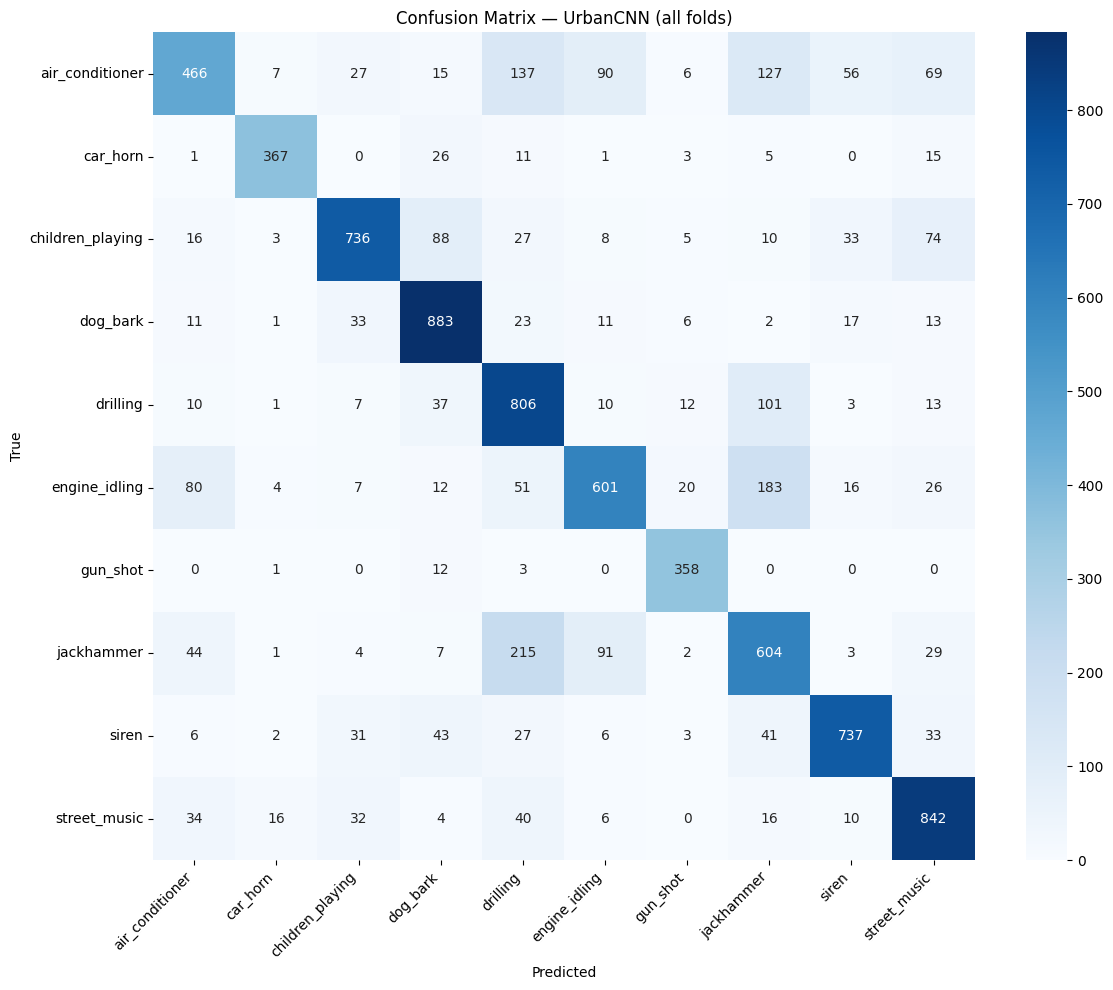

Saved to Drive.


In [13]:
# ── Cell 12: Confusion matrix (run after all folds complete) ─────
# Aggregates predictions across all folds for a full-dataset confusion matrix

meta = load_metadata(DATASET_ROOT)
all_labels, all_preds = [], []

for test_fold, train_df, test_df in get_fold_splits(meta):
    ckpt = os.path.join(CHECKPOINT_DIR, f'fold{test_fold}_best.pt')
    if not os.path.exists(ckpt):
        print(f'Missing checkpoint for fold {test_fold}')
        continue

    test_ds = MelDataset(test_df, DATASET_ROOT, augment=False)
    test_loader = DataLoader(test_ds, batch_size=64, shuffle=False,
                              num_workers=2, pin_memory=True)

    model = UrbanCNN().to(DEVICE)
    model.load_state_dict(safe_torch_load(ckpt, map_location=DEVICE))

    labels, preds = eval_model(model, test_loader)
    all_labels.extend(labels.tolist())
    all_preds.extend(preds.tolist())
    torch.cuda.empty_cache()

print(f'Overall accuracy: {accuracy_score(all_labels, all_preds)*100:.2f}%')

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Confusion Matrix — UrbanCNN (all folds)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'confusion_matrix.png'), dpi=150)
plt.show()
print('Saved to Drive.')

---
# Part 6: ⭐ Novel Contribution — Noise Robustness Analysis

## Motivation

Most published benchmarks, including UrbanSound8K's own leaderboard, report **clean-data accuracy only**. This ignores the deployment reality: urban sound classifiers are used *in* urban environments, which are inherently noisy.

**Real deployment scenarios:**
- Smart city microphones exposed to traffic, wind, HVAC systems
- Autonomous vehicle audio sensors in rainy or windy conditions
- Surveillance systems in public spaces with crowd noise

**The key question this experiment answers:**
> *If you deploy CNN vs. SVM in a noisy environment, which model fails more gracefully?*

---

## Experimental Protocol

**What we inject:** Additive White Gaussian Noise (AWGN) — the simplest noise model, widely used as a standard benchmark for robustness testing.

**SNR (Signal-to-Noise Ratio):** Measures how much louder the signal is than the noise:

$$\text{SNR (dB)} = 10 \cdot \log_{10}\left(\frac{P_{\text{signal}}}{P_{\text{noise}}}\right)$$

| SNR | Interpretation |
|-----|---------------|
| 20 dB | Signal 100× stronger than noise — mild degradation |
| 10 dB | Signal 10× stronger — moderate noise |
| 5 dB | Signal ~3× stronger — significant noise |
| 0 dB | Signal = Noise — heavily corrupted |
| -5 dB | Noise stronger than signal — near-unintelligible |

**Important:** Noise is injected **post-hoc** to the test set only — neither model is retrained. This simulates deploying a model trained in a lab into a noisy real-world environment, which is the actual deployment scenario.

**Why does the representation matter for noise?**
- **MFCCs:** The cepstral transform partially decorrelates spectral features. Additive noise in the waveform becomes additive noise across all mel bins, but the DCT compresses this into the lower cepstral coefficients. MFCCs have some inherent noise resistance.
- **Mel spectrograms:** Noise adds broadband energy across all frequency bins at all time steps — this visually "floods" the spectrogram. The CNN must separate meaningful patterns from a noisy background it was never trained on.

## Cell 13 — Noise Injection & Experiment Setup

Defines the `add_gaussian_noise()` function and sets up the noise experiment parameters.

### `add_gaussian_noise(audio, snr_db)`
Computes the target noise power from the signal power and desired SNR, then adds zero-mean Gaussian noise:

```
noise_power = signal_power / 10^(snr_db / 10)
noise ~ N(0, sqrt(noise_power))
noisy_audio = audio + noise
```

**Per-clip SNR:** The noise level is computed relative to each clip's own signal power. This means a quiet clip and a loud clip at "0 dB SNR" both have noise at the same relative level — this is the correct approach for a fair comparison across clips with different recording levels.

**Edge case:** If `signal_power == 0` (silent clip), return the original audio unchanged — dividing by zero would produce NaN noise.

In [14]:
# ── Cell 13: Noise robustness — setup ────────────────────────────
# Novel contribution: characterize how CNN vs SVM degrade under
# additive Gaussian noise without retraining (zero-shot robustness)

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

SNR_LEVELS   = [20, 10, 5, 0, -5]   # dB levels to test
NOISE_OUTPUT = os.path.join(RESULTS_DIR, 'noise_results.json')

def add_gaussian_noise(audio, snr_db):
    """
    Add Additive White Gaussian Noise (AWGN) at a target SNR level.

    SNR (dB) = 10 * log10(P_signal / P_noise)
    => P_noise = P_signal / 10^(SNR/10)

    Args:
        audio: float32 numpy array, waveform
        snr_db: target signal-to-noise ratio in decibels

    Returns:
        Noisy waveform (same shape and dtype as input)
    """
    signal_power = np.mean(audio ** 2)
    if signal_power == 0:           # silent clip — avoid division by zero
        return audio
    noise_power = signal_power / (10 ** (snr_db / 10.0))
    noise = np.random.normal(0, np.sqrt(noise_power), audio.shape).astype(np.float32)
    return audio + noise

print('Noise utilities defined.')
print(f'Testing SNR levels: {SNR_LEVELS} dB  +  clean baseline')

Noise utilities defined.
Testing SNR levels: [20, 10, 5, 0, -5] dB  +  clean baseline


## Cell 14 — Run Noise Robustness Experiment

The main loop. For each of the 10 folds and each SNR level (+ clean):
1. **CNN:** Load the saved best checkpoint, run inference on noisy mel spectrograms
2. **SVM:** Retrain from scratch on clean MFCC features, run inference on noisy MFCC features

**Why retrain SVM per fold here?**
The SVM from Cell 9 used a global train/test split loop and didn't save per-fold models. Here we retrain it fresh for each fold to ensure the comparison is apples-to-apples — both models see the same training data and the same noisy test data.

**Compatibility notes:**
- Uses the same `extract_mel()` function defined in Cell 5 (with `fmax=8000` and [0,1] normalization) — critical for matching the CNN's training distribution
- Uses the same MFCC cache from Cell 9 (`CACHE_DIR/mfcc.npz`) for clean features; noisy MFCC features are extracted fresh
- Loads checkpoints from `CHECKPOINT_DIR/foldN_best.pt` — same path used by Cell 10

**Expected runtime:** ~30–60 minutes on T4 GPU (10 folds × 6 noise levels × ~800 test clips each)

In [15]:
# ── Cell 14: Run noise robustness experiment ─────────────────────
# ~30-60 min on T4. Results saved to Drive automatically.
# Safe to re-run: loads existing results if already complete.

if os.path.exists(NOISE_OUTPUT):
    print('Noise results already exist. Loading from Drive...')
    with open(NOISE_OUTPUT) as f:
        noise_data = json.load(f)
    summary = noise_data['results']
    snr_list = noise_data['snr_levels']
    print('Loaded existing results. Skip to Cell 15 to visualize.')
else:
    meta = load_metadata(DATASET_ROOT)

    # ── Load clean MFCC cache (from Cell 9) ──────────────────────────
    mfcc_cache = os.path.join(CACHE_DIR, 'mfcc.npz')
    if os.path.exists(mfcc_cache):
        cache = np.load(mfcc_cache)
        X_mfcc_clean, y_all, folds_all = cache['X'], cache['y'], cache['folds']
        print('Loaded MFCC cache.')
    else:
        # Extract from scratch if cache missing
        print('Cache not found — extracting MFCCs (this takes ~10 min)...')
        X_mfcc_clean, y_all, folds_all = [], [], []
        for i, row in meta.iterrows():
            path = audio_path(DATASET_ROOT, row['fold'], row['slice_file_name'])
            audio = load_audio(path)
            X_mfcc_clean.append(extract_mfcc(audio))
            y_all.append(row['classID'])
            folds_all.append(row['fold'])
            if (i+1) % 1000 == 0: print(f'  {i+1}/{len(meta)}')
        X_mfcc_clean = np.array(X_mfcc_clean, dtype=np.float32)
        y_all        = np.array(y_all,         dtype=np.int64)
        folds_all    = np.array(folds_all)
        np.savez(mfcc_cache, X=X_mfcc_clean, y=y_all, folds=folds_all)

    snr_list = ['clean'] + SNR_LEVELS
    # Store per-fold results keyed by SNR label
    results = {str(snr): {'cnn': [], 'svm': []} for snr in snr_list}

    for test_fold in range(1, 11):
        print(f'\n── Fold {test_fold} ──')
        test_mask  = (folds_all == test_fold)
        train_mask = ~test_mask
        test_rows  = meta[meta['fold'] == test_fold].reset_index(drop=True)
        y_test     = y_all[test_mask]

        # ── CNN: load saved best checkpoint ──────────────────────────
        ckpt_path = os.path.join(CHECKPOINT_DIR, f'fold{test_fold}_best.pt')
        model = UrbanCNN().to(DEVICE)
        ckpt  = safe_torch_load(ckpt_path, map_location=DEVICE)
        # Handle both bare state_dict and wrapped checkpoint formats
        if isinstance(ckpt, dict) and 'model' in ckpt:
            model.load_state_dict(ckpt['model'])
        else:
            model.load_state_dict(ckpt)
        model.eval()

        # ── SVM: retrain on this fold's training split ────────────────
        svm = Pipeline([
            ('scaler', StandardScaler()),
            ('svm',    SVC(kernel='rbf', C=10, gamma='scale', decision_function_shape='ovr'))
        ])
        svm.fit(X_mfcc_clean[train_mask], y_all[train_mask])
        print(f'  SVM trained on {train_mask.sum()} samples')

        # ── Evaluate at each SNR level ────────────────────────────────
        for snr in snr_list:
            mel_batch, mfcc_batch = [], []

            for _, row in test_rows.iterrows():
                path  = audio_path(DATASET_ROOT, row['fold'], row['slice_file_name'])
                audio = load_audio(path)

                # Apply noise to raw waveform BEFORE feature extraction
                audio_noisy = add_gaussian_noise(audio, snr) if snr != 'clean' else audio

                mel_batch.append(extract_mel(audio_noisy))    # for CNN
                mfcc_batch.append(extract_mfcc(audio_noisy))  # for SVM

            # CNN inference
            mel_tensor = torch.tensor(np.array(mel_batch)).unsqueeze(1).to(DEVICE)
            with torch.no_grad():
                cnn_preds = model(mel_tensor).argmax(dim=1).cpu().numpy()
            cnn_acc = float(accuracy_score(y_test, cnn_preds))

            # SVM inference
            svm_preds = svm.predict(np.array(mfcc_batch, dtype=np.float32))
            svm_acc   = float(accuracy_score(y_test, svm_preds))

            results[str(snr)]['cnn'].append(cnn_acc)
            results[str(snr)]['svm'].append(svm_acc)

            tag = f'{snr:>4} dB' if snr != 'clean' else '  clean'
            print(f'  {tag} | CNN={cnn_acc*100:.1f}%  SVM={svm_acc*100:.1f}%')

        torch.cuda.empty_cache()

    # ── Aggregate to mean ± std per SNR level ────────────────────────
    summary = {}
    for snr in snr_list:
        cnn_accs = results[str(snr)]['cnn']
        svm_accs = results[str(snr)]['svm']
        summary[str(snr)] = {
            'cnn_mean':  float(np.mean(cnn_accs)),
            'cnn_std':   float(np.std(cnn_accs)),
            'svm_mean':  float(np.mean(svm_accs)),
            'svm_std':   float(np.std(svm_accs)),
            'cnn_folds': cnn_accs,
            'svm_folds': svm_accs,
        }

    # ── Print summary table ───────────────────────────────────────────
    print('\n── Noise Robustness Summary ──')
    print(f'{"SNR":>8}  {"CNN (%)":>10}  {"SVM (%)":>10}  {"Gap (pp)":>10}')
    print('─' * 46)
    for snr in snr_list:
        s = summary[str(snr)]
        gap   = (s['cnn_mean'] - s['svm_mean']) * 100
        label = f'{snr} dB' if snr != 'clean' else 'clean'
        print(f'{label:>8}  {s["cnn_mean"]*100:>8.2f}%  {s["svm_mean"]*100:>8.2f}%  {gap:>+9.2f}')

    # ── Save results to Drive ─────────────────────────────────────────
    with open(NOISE_OUTPUT, 'w') as f:
        json.dump({'snr_levels': snr_list, 'results': summary}, f, indent=2)
    print(f'\nSaved to {NOISE_OUTPUT}')

Loaded MFCC cache.

── Fold 1 ──
  SVM trained on 7859 samples
    clean | CNN=72.9%  SVM=60.0%
    20 dB | CNN=74.3%  SVM=57.7%
    10 dB | CNN=68.5%  SVM=53.0%
     5 dB | CNN=64.8%  SVM=44.0%
     0 dB | CNN=61.7%  SVM=29.2%
    -5 dB | CNN=54.8%  SVM=20.8%

── Fold 2 ──
  SVM trained on 7844 samples
    clean | CNN=67.7%  SVM=65.8%
    20 dB | CNN=69.8%  SVM=60.2%
    10 dB | CNN=67.0%  SVM=54.4%
     5 dB | CNN=65.4%  SVM=44.6%
     0 dB | CNN=64.4%  SVM=29.7%
    -5 dB | CNN=58.7%  SVM=18.7%

── Fold 3 ──
  SVM trained on 7807 samples
    clean | CNN=66.8%  SVM=60.5%
    20 dB | CNN=68.3%  SVM=53.5%
    10 dB | CNN=64.8%  SVM=45.7%
     5 dB | CNN=63.1%  SVM=35.5%
     0 dB | CNN=58.7%  SVM=20.6%
    -5 dB | CNN=49.3%  SVM=14.5%

── Fold 4 ──
  SVM trained on 7742 samples
    clean | CNN=72.5%  SVM=65.5%
    20 dB | CNN=73.6%  SVM=57.0%
    10 dB | CNN=68.7%  SVM=46.2%
     5 dB | CNN=65.6%  SVM=40.0%
     0 dB | CNN=58.5%  SVM=29.3%
    -5 dB | CNN=51.7%  SVM=18.0%

── Fold 5 ──

## Cell 15 — Visualize Noise Robustness Results

Produces two publication-quality figures:

**Figure 1 — Degradation Curves:** Accuracy vs. SNR for both models.
Shows the rate of performance degradation and any crossover points.

**Figure 2 — Performance Gap:** CNN advantage (CNN% − SVM%) at each noise level.
Positive = CNN better; negative = SVM better. This directly answers the deployment question.

**What to look for:**
- **Slope:** A steeper curve = less robust to noise
- **Gap at low SNR:** Does the CNN maintain its advantage or does it collapse faster than SVM?
- **Crossover (if any):** The SNR level where SVM becomes the better choice

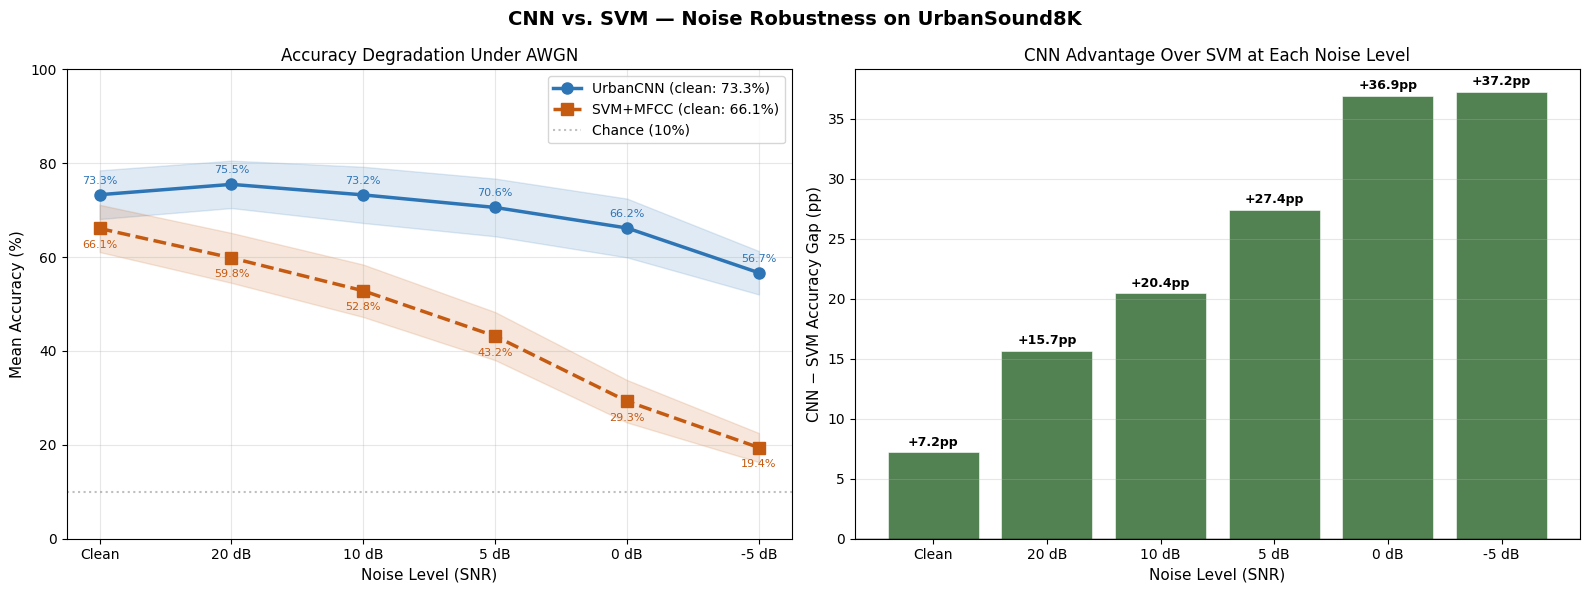

Saved to Drive.


In [16]:
# ── Cell 15: Visualize noise robustness results ───────────────────

# Load results (works whether we just ran the experiment or loaded from Drive)
if 'summary' not in dir() or 'snr_list' not in dir():
    with open(NOISE_OUTPUT) as f:
        noise_data = json.load(f)
    summary = noise_data['results']
    snr_list = noise_data['snr_levels']

# ── Prepare data for plotting ─────────────────────────────────────
snr_labels = ['Clean' if s == 'clean' else f'{s} dB' for s in snr_list]
cnn_means  = [summary[str(s)]['cnn_mean'] * 100 for s in snr_list]
svm_means  = [summary[str(s)]['svm_mean'] * 100 for s in snr_list]
cnn_stds   = [summary[str(s)]['cnn_std']  * 100 for s in snr_list]
svm_stds   = [summary[str(s)]['svm_std']  * 100 for s in snr_list]
gaps       = [c - s for c, s in zip(cnn_means, svm_means)]
x          = range(len(snr_labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('CNN vs. SVM — Noise Robustness on UrbanSound8K', fontsize=14, fontweight='bold')

# ── Plot 1: Degradation curves ────────────────────────────────────
ax1.plot(x, cnn_means, 'o-', color='#2E75B6', linewidth=2.5, markersize=8,
         label=f'UrbanCNN (clean: {cnn_means[0]:.1f}%)')
ax1.fill_between(x,
    [m - s for m, s in zip(cnn_means, cnn_stds)],
    [m + s for m, s in zip(cnn_means, cnn_stds)],
    alpha=0.15, color='#2E75B6')

ax1.plot(x, svm_means, 's--', color='#C55A11', linewidth=2.5, markersize=8,
         label=f'SVM+MFCC (clean: {svm_means[0]:.1f}%)')
ax1.fill_between(x,
    [m - s for m, s in zip(svm_means, svm_stds)],
    [m + s for m, s in zip(svm_means, svm_stds)],
    alpha=0.15, color='#C55A11')

ax1.axhline(y=10, color='gray', linestyle=':', alpha=0.5, label='Chance (10%)')
ax1.set_xticks(x); ax1.set_xticklabels(snr_labels)
ax1.set_xlabel('Noise Level (SNR)', fontsize=11)
ax1.set_ylabel('Mean Accuracy (%)', fontsize=11)
ax1.set_title('Accuracy Degradation Under AWGN', fontsize=12)
ax1.legend(fontsize=10); ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 100)

# Annotate the clean accuracy values
for i, (c, s) in enumerate(zip(cnn_means, svm_means)):
    ax1.annotate(f'{c:.1f}%', (i, c), textcoords='offset points',
                 xytext=(0, 8), ha='center', fontsize=8, color='#2E75B6')
    ax1.annotate(f'{s:.1f}%', (i, s), textcoords='offset points',
                 xytext=(0, -14), ha='center', fontsize=8, color='#C55A11')

# ── Plot 2: CNN advantage gap ─────────────────────────────────────
colors = ['#276227' if g >= 0 else '#C00000' for g in gaps]
bars = ax2.bar(x, gaps, color=colors, alpha=0.8, edgecolor='white', linewidth=0.5)
ax2.axhline(y=0, color='black', linewidth=1)
ax2.set_xticks(x); ax2.set_xticklabels(snr_labels)
ax2.set_xlabel('Noise Level (SNR)', fontsize=11)
ax2.set_ylabel('CNN − SVM Accuracy Gap (pp)', fontsize=11)
ax2.set_title('CNN Advantage Over SVM at Each Noise Level', fontsize=12)
ax2.grid(True, alpha=0.3, axis='y')

for bar, gap in zip(bars, gaps):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
             f'{gap:+.1f}pp', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'noise_robustness.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved to Drive.')

## Cell 16 — Per-Class Breakdown at Worst SNR

At the worst noise level (-5 dB), which sound classes drive the performance difference between CNN and SVM?

This breakdown reveals whether the CNN's advantage (or SVM's advantage) at low SNR is class-specific — for example, CNN might be better at noisy gunshots but SVM might be better at noisy engine idling. This has practical implications for multi-classifier system design.

Fold 1 done
Fold 2 done
Fold 3 done
Fold 4 done
Fold 5 done
Fold 6 done
Fold 7 done
Fold 8 done
Fold 9 done
Fold 10 done


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


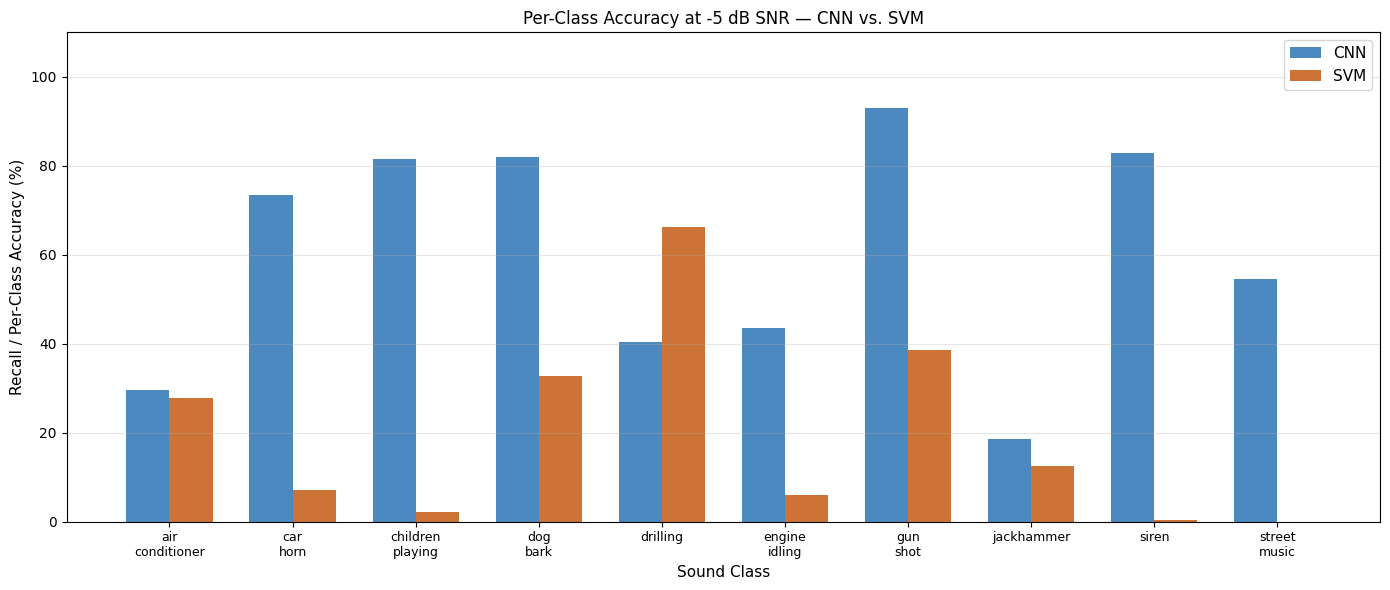


Per-class accuracy at -5 dB SNR:
           Class CNN (%) SVM (%) Gap (pp)
 air_conditioner    29.7    27.7     +2.0
        car_horn    73.4     7.2    +66.2
children_playing    81.5     2.2    +79.3
        dog_bark    82.0    32.8    +49.2
        drilling    40.3    66.2    -25.9
   engine_idling    43.5     6.0    +37.5
        gun_shot    93.0    38.5    +54.5
      jackhammer    18.7    12.5     +6.2
           siren    82.8     0.4    +82.3
    street_music    54.6     0.0    +54.6


In [17]:
# ── Cell 16: Per-class accuracy at worst SNR (-5 dB) ─────────────

# Reload results from Drive if needed
if 'summary' not in dir():
    with open(NOISE_OUTPUT) as f:
        noise_data = json.load(f)
    summary = noise_data['results']
    snr_list = noise_data['snr_levels']

# We need per-class breakdown — re-run fold loop at -5 dB only
# (fast since we only test one noise level)
meta = load_metadata(DATASET_ROOT)
mfcc_cache = os.path.join(CACHE_DIR, 'mfcc.npz')
cache = np.load(mfcc_cache)
X_mfcc_clean, y_all, folds_all = cache['X'], cache['y'], cache['folds']

worst_snr = -5
all_cnn_labels, all_cnn_preds = [], []
all_svm_labels, all_svm_preds = [], []

for test_fold in range(1, 11):
    test_mask  = (folds_all == test_fold)
    train_mask = ~test_mask
    test_rows  = meta[meta['fold'] == test_fold].reset_index(drop=True)
    y_test     = y_all[test_mask]

    # CNN
    ckpt_path = os.path.join(CHECKPOINT_DIR, f'fold{test_fold}_best.pt')
    model = UrbanCNN().to(DEVICE)
    ckpt  = safe_torch_load(ckpt_path, map_location=DEVICE)
    if isinstance(ckpt, dict) and 'model' in ckpt:
        model.load_state_dict(ckpt['model'])
    else:
        model.load_state_dict(ckpt)
    model.eval()

    # SVM
    svm = Pipeline([('scaler', StandardScaler()),
                    ('svm', SVC(kernel='rbf', C=10, gamma='scale', decision_function_shape='ovr'))])
    svm.fit(X_mfcc_clean[train_mask], y_all[train_mask])

    mel_batch, mfcc_batch = [], []
    for _, row in test_rows.iterrows():
        audio = load_audio(audio_path(DATASET_ROOT, row['fold'], row['slice_file_name']))
        audio_noisy = add_gaussian_noise(audio, worst_snr)
        mel_batch.append(extract_mel(audio_noisy))
        mfcc_batch.append(extract_mfcc(audio_noisy))

    mel_tensor = torch.tensor(np.array(mel_batch)).unsqueeze(1).to(DEVICE)
    with torch.no_grad():
        cnn_preds = model(mel_tensor).argmax(1).cpu().numpy()

    svm_preds = svm.predict(np.array(mfcc_batch, dtype=np.float32))

    all_cnn_labels.extend(y_test.tolist())
    all_cnn_preds.extend(cnn_preds.tolist())
    all_svm_labels.extend(y_test.tolist())
    all_svm_preds.extend(svm_preds.tolist())

    torch.cuda.empty_cache()
    print(f'Fold {test_fold} done')

# Per-class accuracy
from sklearn.metrics import classification_report
import pandas as pd

cnn_report = classification_report(all_cnn_labels, all_cnn_preds,
                                    target_names=CLASSES, output_dict=True)
svm_report = classification_report(all_svm_labels, all_svm_preds,
                                    target_names=CLASSES, output_dict=True)

class_names = CLASSES
cnn_per_class = [cnn_report[c]['precision'] * 100 for c in class_names]  # use recall for per-class acc
cnn_per_class = [cnn_report[c]['recall']    * 100 for c in class_names]
svm_per_class = [svm_report[c]['recall']    * 100 for c in class_names]
gaps_per_class= [c - s for c, s in zip(cnn_per_class, svm_per_class)]

# Plot
fig, ax = plt.subplots(figsize=(14, 6))
x_pos = np.arange(len(class_names))
width = 0.35

bars1 = ax.bar(x_pos - width/2, cnn_per_class, width, label='CNN', color='#2E75B6', alpha=0.85)
bars2 = ax.bar(x_pos + width/2, svm_per_class, width, label='SVM', color='#C55A11', alpha=0.85)

ax.set_xlabel('Sound Class', fontsize=11)
ax.set_ylabel('Recall / Per-Class Accuracy (%)', fontsize=11)
ax.set_title(f'Per-Class Accuracy at {worst_snr} dB SNR — CNN vs. SVM', fontsize=12)
ax.set_xticks(x_pos)
ax.set_xticklabels([c.replace('_', '\n') for c in class_names], fontsize=9)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 110)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, f'per_class_noise_{abs(worst_snr)}db.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'\nPer-class accuracy at {worst_snr} dB SNR:')
df = pd.DataFrame({'Class': class_names, 'CNN (%)': [f"{v:.1f}" for v in cnn_per_class],
                   'SVM (%)': [f"{v:.1f}" for v in svm_per_class],
                   'Gap (pp)': [f"{v:+.1f}" for v in gaps_per_class]})
print(df.to_string(index=False))

---
## Git Push

Run this cell to push all changes (including this notebook) to GitHub.

In [18]:
# ── Git Push ──────────────────────────────────────────────────────
!git config --global user.email "dun011@ucsd.edu"
!git config --global user.name "DanielNg520"

!git add -A
!git commit -m "Add noise robustness experiment and documented notebook"
!git push

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
Everything up-to-date
